In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp
import scipy

# 23/03/2025

In [2]:
def speed(v):
    return sqrt(np.sum(v**2))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc
    

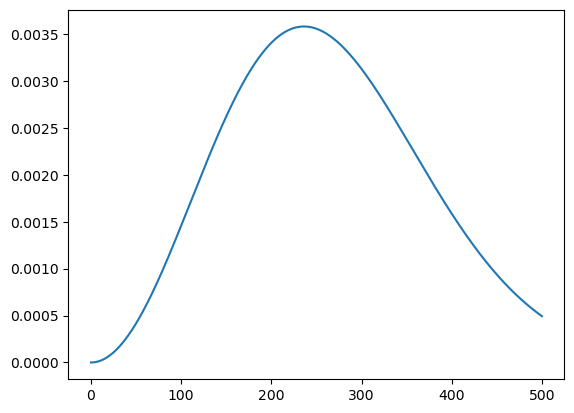

In [123]:
# example of single gaussian/stream

plt.clf()
v = np.linspace(0, 500, 10000)
sig = 167
f = speedDistGaussian(v, sig, 1)
plt.plot(v, f)

In [4]:
def streamN(v):
    sigg = 2.58
    sige = 5.6
    c_0 = 1.1
    f1 = exp(-0.5 * v**2 / sigg**2)
    f2 = c_0 * exp(- np.abs(v) / sige)
    return f1+f2

<Figure size 640x480 with 0 Axes>

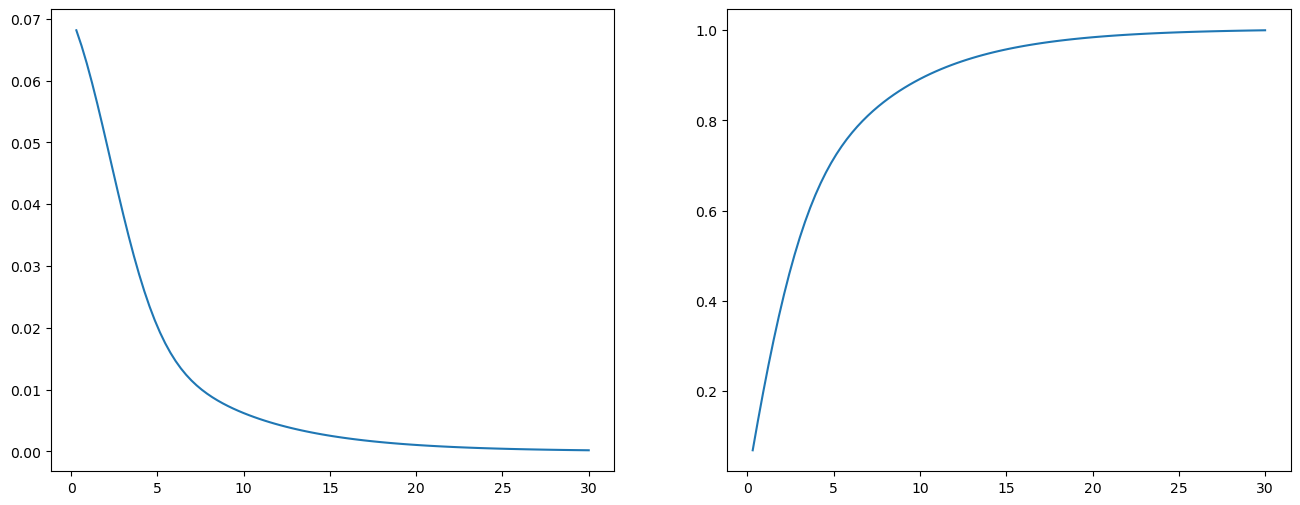

In [22]:
#from https://iopscience.iop.org/article/10.3847/1538-4357/ad7b35
#using random constant values for now
# this is just a placeholder to find a value for N_str, i didn't read thru the full paper
# the paper produces the plots below based on radial velocity?

v = np.linspace(0, 30, 100)[1:] # the paper goes from -20 to 20, \
    #however we don't care the direction only the speed of the stream
    # maybe need to change the maximum velocity??
y = streamN(v) / np.sum(streamN(v))
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, y)
ax[1].plot(v, y.cumsum())

v_str = np.column_stack((v, y))
#np.random.seed(0)
#v_str = np.random.choice(a=v, p=y, size = 1000)



In [ ]:
np.random.seed(0)
v_strs = np.random.choice(a=v, p=y, size = 10000)
y = streamN(v_strs)
y = y / np.sum(y)
v_str = np.column_stack((v_strs, y))

In [25]:
v = np.linspace(0, 30, 1000)[1:]

f = []
sig = 0.005
for i in v_str:
    v_c = i[0]
    p = i[1]
    f.append(p* speedDistGaussian(v, sig, v_c))

f = np.array(f)

<Figure size 640x480 with 0 Axes>

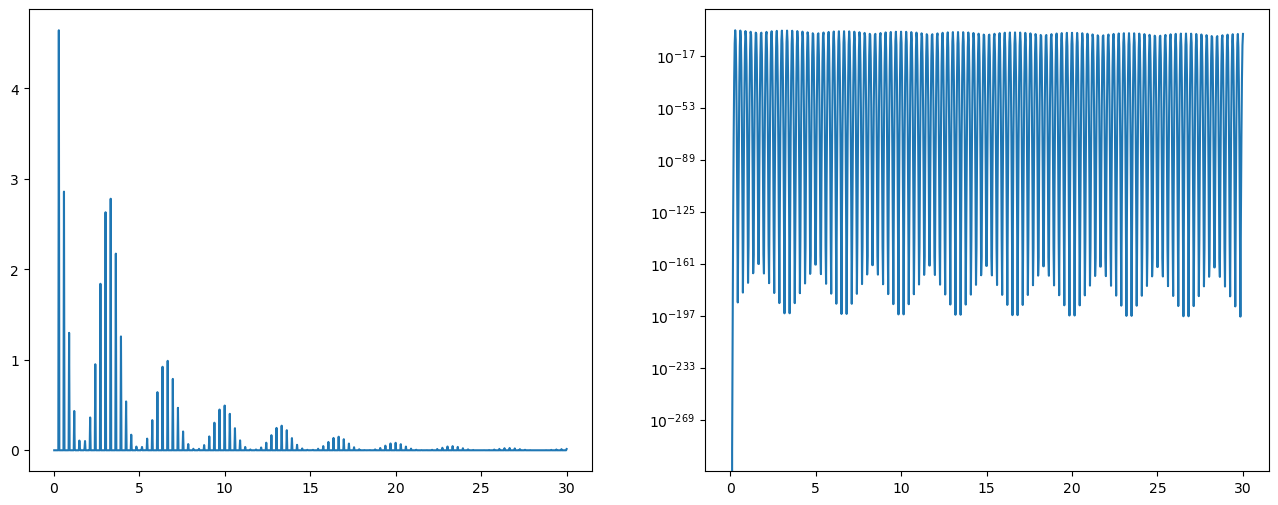

In [26]:
plt.clf()
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, f.sum(axis=0))
ax[1].semilogy(v, f.sum(axis=0))

In [47]:
v_str[:, 0]

array([3.12663127, 4.99414994, 3.61773618, ..., 5.74715747, 0.10680107,
       7.03447034], shape=(10000,))

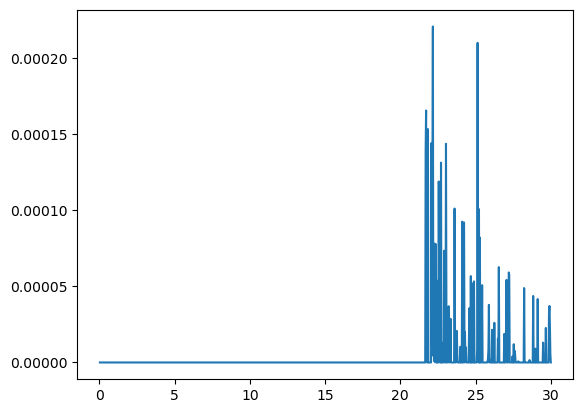

In [79]:
plt.clf()
plt.plot(v, f[np.argsort(v_str[:, 0])][::-1][:100].sum(axis=0))

In [57]:
np.argsort(v_str[:, 0])[::-1]

array([8163, 2749, 5081, ..., 7648, 3856, 2055], shape=(10000,))

In [69]:
f[np.argsort(v_str[:, 0])][::-1][:50].sum(axis=0)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0

In [ ]:
# random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
# look at fine gained structured for rho/M
# velocity of streams 
# phase mixing

# for traferring to signal use A.2 in fine grained
# quality factor q = w_0 / delta w = m_a / m_a / v^2

# 25th to 31st March
## Feedback:
- Better to sample stream velocities from the halo's gaussian distribution. Easy to do this, just use random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
- Each stream should have a different density as well. Specifically we use, f (ρ) = scipy.stats.skewnorm.pdf(log(rho),-2.10,loc=-11.37,scale=7.15)/rho, as shown in Ciaran's Fine-grained dark matter paper
- Look at phase mixing, it tells us about velocity of streams/ how the streams came to be (folds etc.) (optional for now)
- After making a proper model/distribution, look into extracting/transforming it into a signal (A.2. in fine grained.) quality factor q = w_0 / delta w = m_a / m_a / v^2


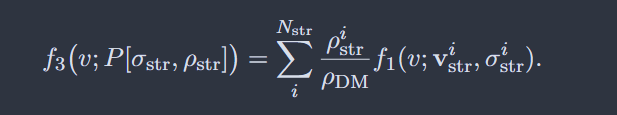

In [28]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [58]:
def fun(rho, str_num):
    return np.abs(scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho - str_num)

def get_density(str_num):
    # returns the optimum stream density to get 
    return scipy.optimize.minimize(fun, x0 = 2.04e-3, bounds = [(7.7e-8, np.inf)], args=[str_num]).x[0]

v_c = np.array([[218, -119, 21]]) # just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 1000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num)
spd = speed(vel + v_c)

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([spd, rho])


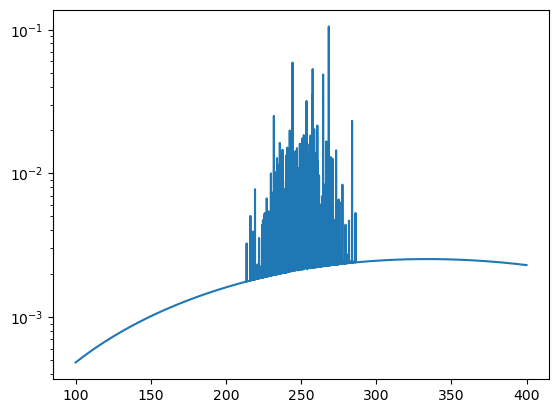

In [60]:
plt.clf()
deltas = []
sig = 0.01 # ask ciaran what do to about the dispersion velocities
v = np.linspace(100, 400, 5000)
for v_e, p in streams:
    gauss = p * speedDistGaussian(v, sig, v_e)
    deltas.append(gauss)

perturb = np.sum(deltas, axis = 0)
total = speedDistGaussian(v, 167, speed(v_c)) * (1 - np.sum(rho)) + perturb

plt.semilogy(v, total)

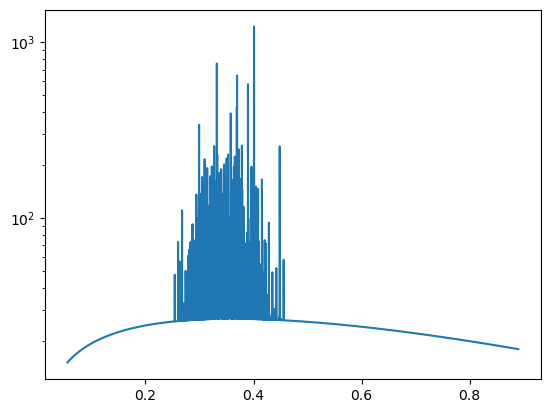

In [62]:
m_a = 1e-6 # in eV
lineshape = np.pi * total / (m_a *v) # T -> infty

w = (v*v/con.c / con.c *1e6 + 2)*m_a / 2
plt.clf()
plt.semilogy((w/m_a - 1) * 1e6, lineshape)

In [183]:
# CONVERT IT FOR LOCAL SUN

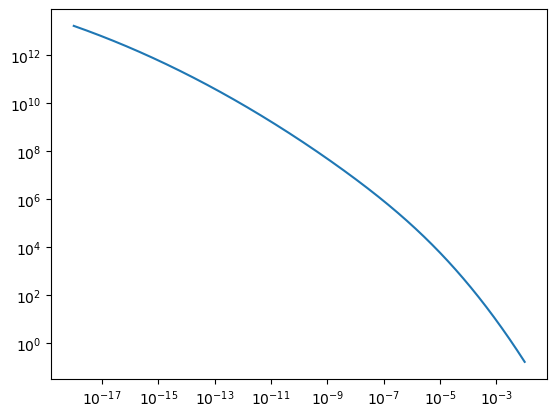

In [38]:
rho = np.logspace(-18, -2, 1000)
f = scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho
plt.clf()
plt.loglog(rho, f)

# 15th April -

In [2]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [90]:
v_c = np.array([[218, -119, 21]]) # just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 10000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num) #+ np.array([12.9, 245.6, 7.78])

(array([  40.,   89.,  149.,  229.,  295.,  361.,  538.,  686.,  897.,
        1590., 1697., 1010.,  669.,  529.,  424.,  285.,  210.,  163.,
         102.,   37.]),
 array([-1.5448053 , -1.39076087, -1.23671645, -1.08267203, -0.92862761,
        -0.77458318, -0.62053876, -0.46649434, -0.31244992, -0.1584055 ,
        -0.00436107,  0.14968335,  0.30372777,  0.45777219,  0.61181661,
         0.76586104,  0.91990546,  1.07394988,  1.2279943 ,  1.38203872,
         1.53608315]),
 <BarContainer object of 20 artists>)

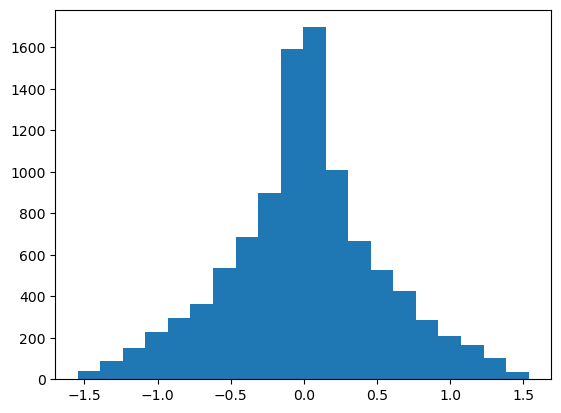

In [126]:
cost = vel[:, 2] / speed(vel)
phi = np.arctan(vel[:, 1] / vel[:, 0])
omega = cost*phi
plt.hist(omega, 20)

In [116]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def v_inf(v):
    r = np.array([[1, 1, 1]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

In [117]:
from scipy.optimize import fsolve

def func(v, vi):
    return (v_inf(v) - vi).T[:, 0]

v = []
for vi in vel:
    root = fsolve(func, [25,25, 25], args=(vi,))
    v.append(root)
v = np.array(v)
v

/tmp/ipykernel_556/2232598548.py:8: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_556/2710740553.py:8: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [25,25, 25], args=(vi,))


array([[25.        , 25.        , 25.        ],
       [25.        , 25.        , 25.        ],
       [-6.20749382, 31.57199296, 29.92085163],
       ...,
       [ 3.90787662, 22.05170478, 39.40213182],
       [ 5.41587824, 28.55032621, 32.79028683],
       [25.        , 25.        , 25.        ]])

In [118]:
mask = np.floor(np.sum(v != [-25, 25, -25], axis = 1)/3).astype(bool)
v = v[mask]
mask.sum()

8382

(array([  1.,   0.,   0.,   0.,  37., 107., 178., 261., 332., 376., 478.,
        594., 755., 883., 932., 912., 908., 737., 540., 351.]),
 array([-0.55947104, -0.4817817 , -0.40409237, -0.32640303, -0.2487137 ,
        -0.17102436, -0.09333503, -0.01564569,  0.06204364,  0.13973298,
         0.21742231,  0.29511165,  0.37280098,  0.45049032,  0.52817965,
         0.60586899,  0.68355832,  0.76124766,  0.83893699,  0.91662633,
         0.99431566]),
 <BarContainer object of 20 artists>)

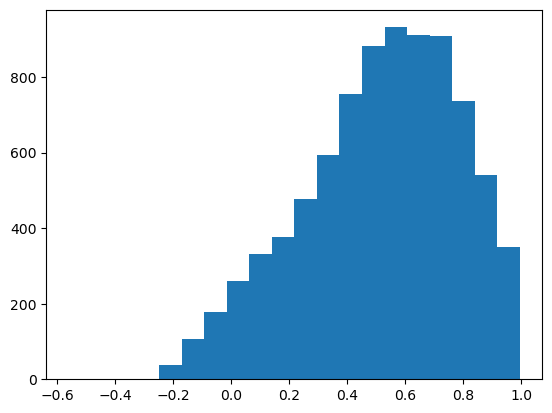

In [120]:
vh = [v[i] / speed(np.array([v[i]])) for i in range(len(v))]
vh = np.array(vh)
plt.hist(vh[:, 0], 20)

(array([  15.,   50.,   87.,   73.,   61.,   39.,   25.,   14.,  108.,
         541., 1474., 1566., 1473., 1115.,  738.,  455.,  280.,  144.,
          96.,   28.]),
 array([-1.52227669, -1.37054271, -1.21880872, -1.06707474, -0.91534075,
        -0.76360677, -0.61187278, -0.4601388 , -0.30840482, -0.15667083,
        -0.00493685,  0.14679714,  0.29853112,  0.45026511,  0.60199909,
         0.75373308,  0.90546706,  1.05720104,  1.20893503,  1.36066901,
         1.512403  ]),
 <BarContainer object of 20 artists>)

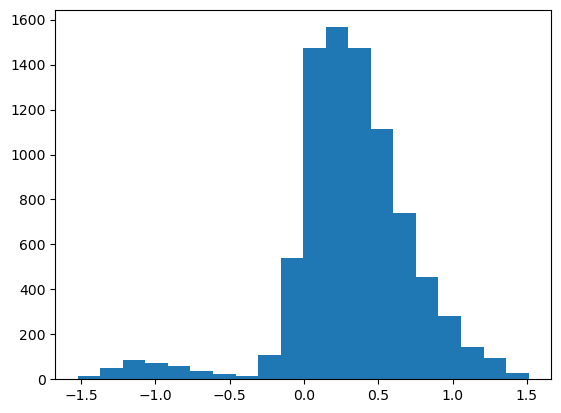

In [124]:
cost = v[:, 2] / speed(v)
phi = np.arctan(v[:, 1] / v[:, 0])
omega1 = cost*phi
plt.hist(omega1, 20)

array([  -2.,   -2.,   -2.,   -9.,   -5.,  -13.,   -1.,   -7.,   -8.,
        -14.,  -12.,  -17.,  -16.,   -3.,  -23.,  -15.,  -28.,  -32.,
        -39.,  -29.,  -34.,  -48.,  -45.,  -48.,  -63.,  -56.,  -57.,
        -65.,  -75.,  -73.,  -87., -103., -113., -116., -116., -139.,
       -129., -129., -156., -143., -163., -166., -168., -173., -160.,
       -152., -193., -221., -265., -341.,  -45.,   -1.,   13.,   44.,
         53.,  124.,  134.,  110.,  162.,  181.,  156.,  191.,  144.,
        162.,  133.,  132.,  117.,  108.,  107.,   72.,   76.,   65.,
         47.,   26.,   43.,   47.,   35.,   14.,   25.,    6.,   18.,
          5.,   -2.,    9.,   -1.,  -18.,    0.,    1.,   -4.,   -6.,
          0.,   -8.,   -3.,   -4.,   -7.,    0.,   -2.,   -3.,    0.])

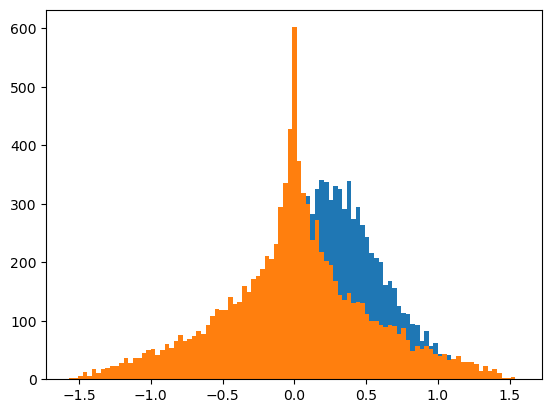

In [130]:
plt.clf()

bins = np.linspace(- np.pi / 2, np.pi/2, 100)
plt.hist(omega1, bins)[0] - plt.hist(omega, bins)[0]

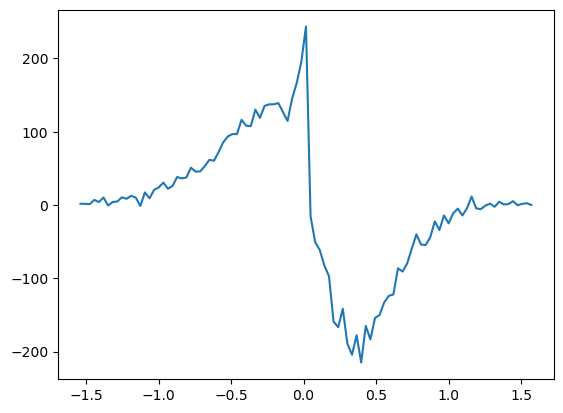

In [133]:
y = plt.hist(omega, bins)[0] * np.sum(mask)/10000 - plt.hist(omega1, bins)[0]
plt.clf()
plt.plot(bins[1:], y)